# Training YOLO detectors on EXOD

A quick walk-through of how to train, validate, and run inference with an Ultralytics YOLO model on the **Extreme Weather Object Detection (EXOD)** dataset.

The dataset ships in standard YOLO format under `../dataset/`:

```
dataset/
├── data.yaml           # 6 classes: person, car, truck, motorcycle, bus, bike
├── train/{images,labels}/
├── valid/{images,labels}/
└── test/{images,labels}/
```

Image filenames are prefixed by weather type — `heavy_` (rain), `snow_`, `fog_`, `dust_`, `flooding_`, `tornado_`, `wildfire_` — which lets you slice metrics per-weather without extra annotation.

This notebook trains a small YOLO11n for a few epochs so it finishes on a single GPU in minutes. For the full paper sweep see `train_detection.py`.

## 1. Setup

Install Ultralytics and other libraries

In [1]:
%pip install -q -U ultralytics matplotlib pillow pyyaml

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.63.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [9]:
from pathlib import Path
import yaml
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from ultralytics import YOLO

DATA_ROOT = Path('../dataset').resolve()
DATA_YAML = DATA_ROOT / 'data.yaml'
assert DATA_YAML.exists(), f'data.yaml not found at {DATA_YAML}'
DATA_YAML

PosixPath('/home/kuanting/research/extreme_weather/dataset/data.yaml')

## 2. Dataset overview

Print the class list and count images per split and per weather type.

In [3]:
cfg = yaml.safe_load(DATA_YAML.read_text())
CLASSES = cfg['names']
print('Classes:', CLASSES)

WEATHERS = ['heavy', 'snow', 'fog', 'dust', 'flooding', 'tornado', 'wildfire']  # 'heavy' = rain

for split in ['train', 'valid', 'test']:
    imgs = list((DATA_ROOT / split / 'images').iterdir())
    by_w = {w: sum(1 for f in imgs if f.name.startswith(f'{w}_')) for w in WEATHERS}
    print(f'{split:5s}  total={len(imgs):>5d}  ' +
          '  '.join(f'{w}={n}' for w, n in by_w.items()))

Classes: ['person', 'car', 'truck', 'motorcycle', 'bus', 'bike']
train  total= 5945  heavy=301  snow=812  fog=166  dust=285  flooding=3089  tornado=892  wildfire=400
valid  total= 1744  heavy=106  snow=44  fog=37  dust=130  flooding=1056  tornado=124  wildfire=247
test   total= 2321  heavy=258  snow=347  fog=103  dust=145  flooding=1006  tornado=148  wildfire=314


## 3. Visualize a labeled sample

YOLO labels are `class cx cy w h` in normalized image coordinates. Render a few training images with their boxes.

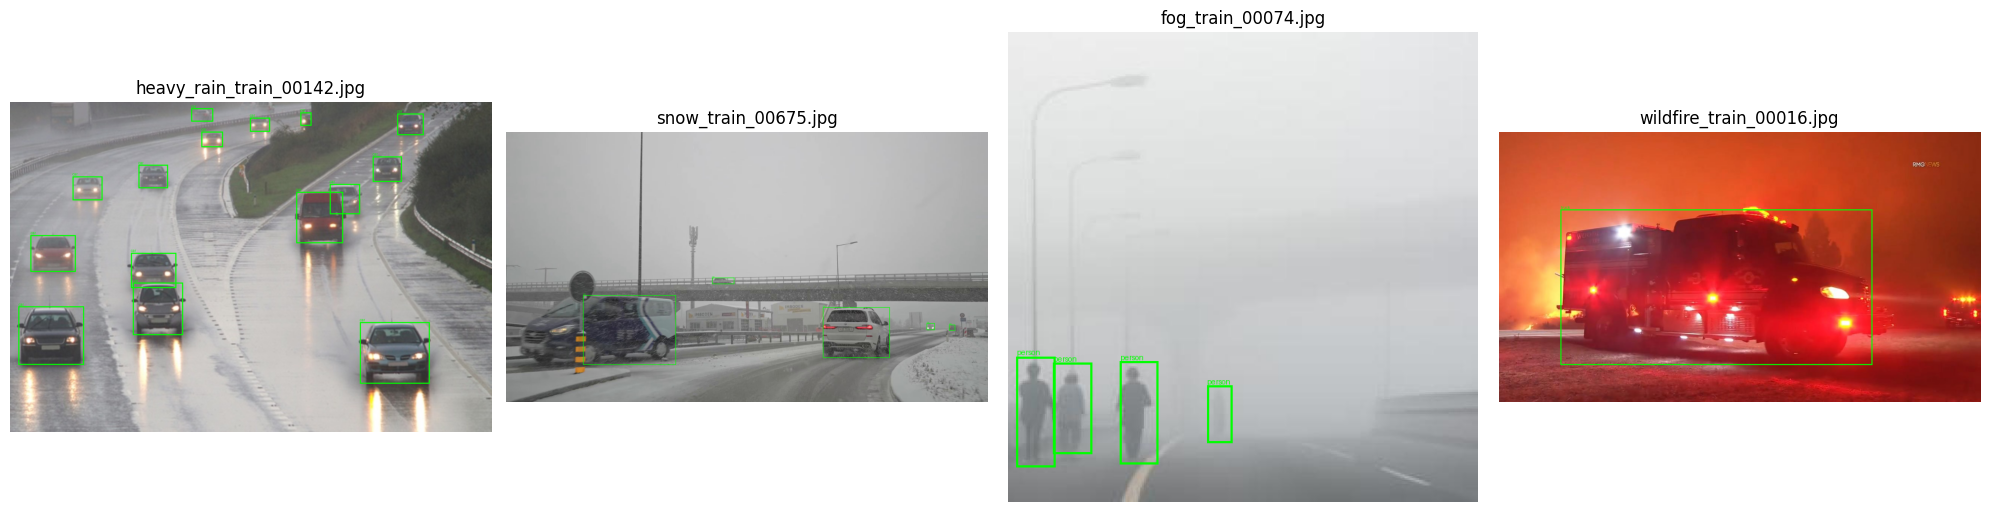

In [4]:
def draw_yolo(img_path: Path):
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    draw = ImageDraw.Draw(img)
    lab = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
    if lab.exists():
        for line in lab.read_text().splitlines():
            c, cx, cy, w, h = map(float, line.split())
            x0, y0 = (cx - w / 2) * W, (cy - h / 2) * H
            x1, y1 = (cx + w / 2) * W, (cy + h / 2) * H
            draw.rectangle([x0, y0, x1, y1], outline='lime', width=3)
            draw.text((x0, max(0, y0 - 12)), CLASSES[int(c)], fill='lime')
    return img

samples = [
    next((DATA_ROOT / 'train' / 'images').glob(f'{w}_*.jpg'))
    for w in ['heavy', 'snow', 'fog', 'wildfire']
]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, p in zip(axes, samples):
    ax.imshow(draw_yolo(p))
    ax.set_title(p.name); ax.axis('off')
plt.tight_layout()

## 4. Train

Pick a model variant (`yolo11n.pt` for a quick demo, swap to `yolo11m.pt` / `yolov8m.pt` / `yolo26m.pt` for paper-grade runs) and call `model.train()`. Weights are downloaded on first use.

The defaults below — 5 epochs at `imgsz=640` — finish in a few minutes on one GPU. Bump `EPOCHS` to 100 to match the paper sweep.

In [6]:
MODEL  = 'yolo11n.pt'   # try 'yolov8m.pt', 'yolo11m.pt', 'yolo26m.pt' for stronger baselines
EPOCHS = 5              # demo run; paper uses 100
IMGSZ  = 640
DEVICE = 0              # GPU index, or 'cpu'

model = YOLO(MODEL)
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    device=DEVICE,
    project='runs/exod_demo',
    name=Path(MODEL).stem,
    exist_ok=True,
)
print('weights:', results.save_dir)

Ultralytics 8.4.46 🚀 Python-3.12.9 torch-2.7.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24075MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/kuanting/research/extreme_weather/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=

## 5. Validate

Run validation on the held-out `valid/` split. Ultralytics reports mAP50, mAP50-95, precision, and recall.

In [7]:
metrics = model.val(data=str(DATA_YAML), imgsz=IMGSZ, device=DEVICE, verbose=False)
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'precision : {metrics.box.mp:.4f}')
print(f'recall    : {metrics.box.mr:.4f}')

Ultralytics 8.4.46 🚀 Python-3.12.9 torch-2.7.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24075MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4879.9±2050.3 MB/s, size: 101.5 KB)
val: Scanning /home/kuanting/research/extreme_weather/dataset/valid/labels.cache... 1744 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1744/1744 1.8Git/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 7626. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 109/109 33.0it/s 3.3s0.1s
                   all       1744       7626      0.557      0.418      0.452      0.259
Speed: 0.3ms preprocess, 0.5ms inference, 0.0ms loss, 0.3ms postprocess per 

## 6. Inference on test images

Run the trained model on a few test images and show the predicted boxes.

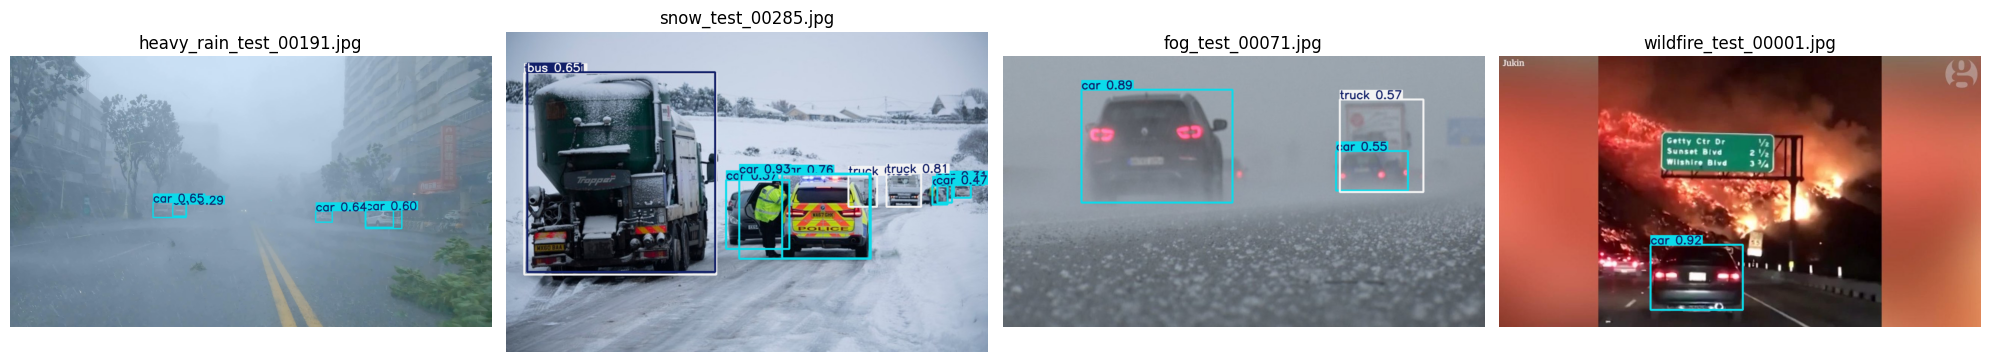

In [8]:
test_imgs = [
    next((DATA_ROOT / 'test' / 'images').glob(f'{w}_*.jpg'))
    for w in ['heavy', 'snow', 'fog', 'wildfire']
]
preds = model.predict(test_imgs, imgsz=IMGSZ, device=DEVICE, conf=0.25, verbose=False)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, r, p in zip(axes, preds, test_imgs):
    ax.imshow(r.plot()[..., ::-1])  # Ultralytics returns BGR
    ax.set_title(p.name); ax.axis('off')
plt.tight_layout()

## 7. Next steps

- **Per-weather eval** — `python eval_detection.py --data ../dataset --weights runs/exod_demo/yolo11n/weights/best.pt --out results/demo.csv` slices metrics by weather prefix.
- **Full sweep (paper Table 3)** — `python train_detection.py --data ../dataset/data.yaml --families 8 11 26 --scales n s m l x --epochs 100`.
- **Leave-one-weather-out (EXOD-Gen)** — `python train_detection.py --data ../dataset --leave-one-out --model yolo11m.pt --epochs 100` trains on 6 weather types and tests on the 7th.
- **Stronger backbones** — swap `MODEL` above to `yolo11m.pt` / `yolo11l.pt` / `yolo26m.pt`. Larger variants take more VRAM but recover several mAP points on `dust` and `wildfire`.